In [64]:
import numpy as np
import math 
import time
import random


# Generation0(初代親)生成
n=50#個体のバイナリデータの桁数
x=100#親の数（ランダムに選ぶ数）
a=[]#親の識別番号
nisinsu=[]
nisinsu_random=[]
# def all_binaries(n):
   
   
#     # for i in range(2**n):# 2のn乗
#     #     bits=[]
#     #     num=i
#     #     for j in range(n):
#     #         bits.insert(0,num%2)
#     #         num //=2
#     #     nisinsu.append(bits)
#     return nisinsu

# binaries=all_binaries(n)
# nisinsu_random=random.sample(nisinsu,x)#生成した全パターンの中からランダムにx個選んで（random.sample(nisinsu,x)の部分）nisinsu_randomに格納
# print(binaries)#複数リストを一つのリストにして表示
# print(nisinsu_random)
# binaries[2][0]#2行目1列目の値（値は0から始まる）
nisinsu_random=np.random.randint(0, 2, (x, n)).tolist()
#評価関数
for i in range(len(nisinsu_random)):
    A,B=0,0  
    for j in range (n):
        if nisinsu_random[i][j]==1:
            A+=math.sqrt(j+1)   
        else:
            B+=math.sqrt(j+1)    
    gosas_genzai=abs(A-B) 
    # a.append(i)# 親の番号をaに格納
    # a.append(nisinsu_random[i])#親のバイナリデータをaに格納
    print(i,")",nisinsu_random[i],",fitness:",gosas_genzai)
# print(a)
    

0 ) [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0] ,fitness: 12.703881625379722
1 ) [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1] ,fitness: 15.089345025233754
2 ) [0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1] ,fitness: 46.89888585034073
3 ) [0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1] ,fitness: 49.50218678355732
4 ) [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1] ,fitness: 32.839122997796366
5 ) [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,

In [65]:
# Generation0を元にGeneration1を生成
def floyd (binary_data):
    A,B=0,0  
    for j in range (n):
        if binary_data[j]==1:
            A+=math.sqrt(j+1)   
        else:
            B+=math.sqrt(j+1)    
    floydpoint=abs(A-B) 
    return floydpoint
    
def gene_update ():
    #gene_best=0# 評価値を更新する変数(onemax版)
    gene_best=500# 評価値を更新する変数(フロイド版)
    elite=[]# 各世代のエリート（評価値が一番良い物）を格納
    # next_gene=[]
    # parents_temp=[]# ルーレット選択用（ランダム式の時は外す）
    for u in range(x):
        
        #どの親を取ってくるか（tournament方式)
        parents=[]
        for _ in range(2):

            parents_temp = random.sample(nisinsu_random, 2)#Generation0のリストからランダムに2つ親を取ってくる
            
            a=floyd(parents_temp[0])
            b=floyd(parents_temp[1])
            

            if a<b:
                parents.append(parents_temp[0])
            elif a>=b:
                parents.append(parents_temp[1])
           
        
        #取ってきた親がGeneration0における何番の親なのか判定
        index_all=[]
        for p in parents:
            index = nisinsu_random.index(p)  # 元のリストでの位置
            # print(f"親データ: {p}  →  位置（インデックス）: {index}")
            index_all.append(index)


        s=random.randint(1, n)#交叉するにあたり、どこで区切るかの数字
    
        offspring_kousa=[]#交叉した結果のバイナリデータを格納するリスト
        for g in range(2):
            if g==0:# 交叉の前半部分
                for h in range(s):
                    offspring_kousa.append(parents[g][h])
            elif g==1: # 交叉の後半部分
                for h in range(s,n,1):
                    offspring_kousa.append(parents[g][h])
                
        mutation_counter=0#突然変異カウンタ。閾値を下回った確率が出たとき（mutation_rateが5%を下回り、突然変異が起こる状態であるとき）このカウンタに1プラスして、突然変異が起こった判断基準にする
        for j in range(n):# 突然変異処理（交叉してできた子供のバイナリデータ一桁一桁に0~1の小数をランダムに割り当て、その値が0.05（5％）より低かったら0,1を反転させる）
            mutation_rate=random.random()
            # print(mutation_rate)
            if mutation_rate<=0.005:
                mutation_counter+=1 
                if offspring_kousa[j]==0:
                    offspring_kousa[j]=1
                elif offspring_kousa[j]==1:
                    offspring_kousa[j]=0
        # next_gene.append(offspring_kousa)  
        nisinsu_random[u]=offspring_kousa # 親データを子供データ（交叉、突然変異処理後）に更新
        # nisinsu_random.append(offspring_kousa)
          
        

        
        #評価関数(フロイド版) 
        A,B=0,0  
        for o in range (n):
            if offspring_kousa[o]==1:
                A+=math.sqrt(o+1)   
            else:
                B+=math.sqrt(o+1)    
        fitness_gen1=abs(A-B) 
        if fitness_gen1<=gene_best:
            gene_best=fitness_gen1#評価値を更新
            # elite=nisinsu_random[u]# そのときの子のデータをエリートとして格納
            elite = offspring_kousa.copy()



        


        
        
        
        """
        #評価関数(OneMax版)
        one_count=0 # 1の数カウンタ
        for o in range(len(offspring_kousa)):#繰り返しの範囲を親、もしくは子供のbinaryデータの桁数に合わせる
            if offspring_kousa[o]==1:
                one_count+=1
        fitness_gen1=one_count
        if fitness_gen1>=gene_best:
            gene_best=fitness_gen1#評価値を更新
            # elite=nisinsu_random[u]# そのときの子のデータをエリートとして格納
            elite = offspring_kousa.copy()
        """




        if mutation_counter>0:
            print(f"{u}）（{index_all[0]},{index_all[1]}）,交叉点位置：{s},子供：{offspring_kousa},fitness:{fitness_gen1}（突然変異発生）")
        else:
            print(f"{u}）（{index_all[0]},{index_all[1]}）,交叉点位置：{s},子供：{offspring_kousa},fitness:{fitness_gen1}")
    print(f"エリート個体は{elite}で、評価値は{gene_best}です")
    nisinsu_random[-1]=elite
    print (nisinsu_random)
    return gene_best
    # next_gene[-1]=elite
    # print(next_gene)
    # return next_gene, elite, gene_best

世代 1
0）（87,62）,交叉点位置：5,子供：[0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1],fitness:52.41587515271961
1）（81,48）,交叉点位置：50,子供：[0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1],fitness:35.81326576796941
2）（91,92）,交叉点位置：27,子供：[1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0],fitness:26.91548847581045
3）（86,32）,交叉点位置：6,子供：[0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1],fitness:4.565759567480313（突然変異発生）
4）（32,32）,交叉点位置：28,子供：[1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1],fitness:16.194181963

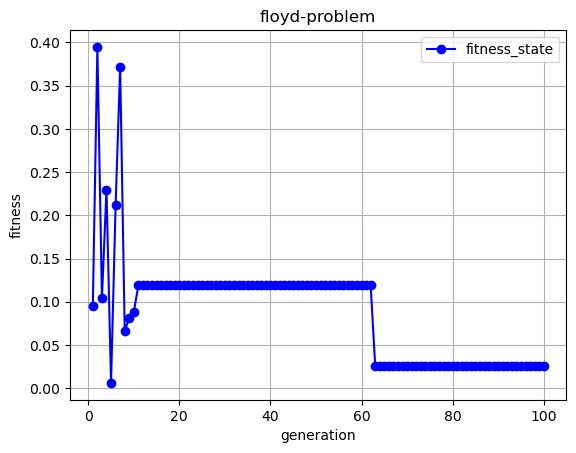

In [66]:
gene_best_all=[]
for i in range (100):
    print("世代",i+1)
    gene_update()
    gene_best_all.append(gene_update())
print(gene_best_all)
import matplotlib.pyplot as plt
# グラフを描く
x= list(range(1, 101))
plt.plot(x, gene_best_all, marker='o', linestyle='-', color='b', label='fitness_state')

# グラフのタイトルやラベルを追加
plt.title("floyd-problem")
plt.xlabel("generation")
plt.ylabel("fitness")
plt.legend()  # 凡例を表示

# グリッド（目盛線）を追加
plt.grid(True)

# グラフを表示
plt.show()    